In [68]:
# basic imports for reading the dolphot output and making plots
import h5py                      # dolphot output is stored as an h5 file
import matplotlib.pyplot as plt  # for the CMD and isochrone plots
import numpy as np               # for the radius cut and quality-cut masks
%matplotlib inline               
#show plots inline in the notebook


In [69]:
# path to the dp0000.h5 file that hst123/dolphot produced for this target
filepath2 = "/Users/mari/Research/summer26/supernovas/sn2018hna/dp0000.h5"
#sn2018hna


In [70]:
#inspect name of stuff inside file
# just checking whether 'photometry' is a group (multiple datasets) or a single
# structured dataset, so I know how to pull individual columns out of it
with h5py.File(filepath2, 'r') as f:
    data = f['photometry']
    
    if isinstance(data, h5py.Group):
        print("Keys inside 'photometry':", list(data.keys()))
    else:
        print("Columns inside 'photometry':", data.dtype.names)
        


Columns inside 'photometry': ('Extension_zero_for_base_image', 'Chip_for_three_dimensional_FITS_image', 'Object_X_position_on_reference_image_or_first_image_if_no_refer', 'Object_Y_position_on_reference_image_or_first_image_if_no_refer', 'Chi_for_fit', 'Signal_to_noise', 'Object_sharpness', 'Object_roundness', 'Direction_of_major_axis_if_not_round', 'Crowding', 'Object_type_1_bright_star_2_faint_3_elongated_4_hot_pixel_5_ext', 'Total_counts_ACS_F555W', 'Total_sky_level_ACS_F555W', 'Normalized_count_rate_ACS_F555W', 'Normalized_count_rate_uncertainty_ACS_F555W', 'Instrumental_VEGAMAG_magnitude_ACS_F555W', 'Transformed_UBVRI_magnitude_ACS_F555W', 'Magnitude_uncertainty_ACS_F555W', 'Chi_ACS_F555W', 'Signal_to_noise_ACS_F555W', 'Sharpness_ACS_F555W', 'Roundness_ACS_F555W', 'Crowding_ACS_F555W', 'Photometry_quality_flag_ACS_F555W', 'Total_counts_ACS_F814W', 'Total_sky_level_ACS_F814W', 'Normalized_count_rate_ACS_F814W', 'Normalized_count_rate_uncertainty_ACS_F814W', 'Instrumental_VEGAMAG_ma

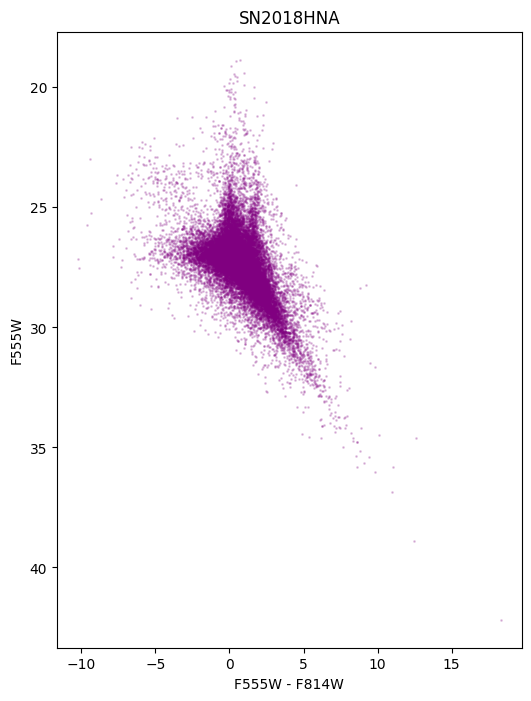

In [71]:
#plotting environment with dp0000.h5 file was is, no radial fix
# first pass CMD with every star in the field, no cuts besides removing dolphot's
# 99.99 "no measurement" flag value. this is before I added the radius cut,
# so it's the whole chip, not just the SN's local environment

import h5py
import matplotlib.pyplot as plt

#data grabbing columns for from photometry
filepath2 = "/Users/mari/Research/summer26/supernovas/sn2018hna/dp0000.h5"
with h5py.File(filepath2, 'r') as f:
    f555 = f['photometry']['Instrumental_VEGAMAG_magnitude_ACS_F555W'][:]
    f814 = f['photometry']['Instrumental_VEGAMAG_magnitude_ACS_F814W'][:]

#filter out the 99.99 error inputs. I'm using 50 as a benchmark because anything dimmer would be incredible faint with HST
valid = (f555 < 50) & (f814 < 50)
f555 = f555[valid]
f814 = f814[valid]

#plotting
plt.figure(figsize=(6, 8))
plt.scatter(f555 - f814, f555, s=1, color="purple", alpha=0.2)   # color-mag scatter, small points since this is the whole field and there is a lot

plt.gca().invert_yaxis() #Brighter stars at the top
plt.xlabel("F555W - F814W")
plt.ylabel("F555W")
plt.title("SN2018HNA")

plt.show()


In [28]:
#finding more info, particularly i want the pixel position for the supernova!!
# dumping every top-level key/attribute so I can see where dolphot/hst123 stored
# the SN's actual coordinates, under 'scraped_photometry'
with h5py.File(filepath2, 'r') as f:
    print("Top-level keys:", list(f.keys()))
    print()
    print("Top-level attributes:", dict(f.attrs))
    print()
    for key in f.keys():
        print(f"--- Group: {key} ---")
        print("  Attributes:", dict(f[key].attrs))
        if hasattr(f[key], 'keys'):
            print("  Sub-keys:", list(f[key].keys()))
        print()



Top-level keys: ['metadata', 'photometry', 'scraped_photometry']

Top-level attributes: {}

--- Group: metadata ---
  Attributes: {'global_param_json': '{\n  "Nimg": "4",\n  "FitSky": "2",\n  "SkipSky": "2",\n  "RCombine": "1.5",\n  "SkySig": "2.25",\n  "SecondPass": "1",\n  "SigFindMult": "0.85",\n  "MaxIT": "25",\n  "NoiseMult": "0.1",\n  "FSat": "0.999",\n  "ApCor": "1",\n  "RCentroid": "2",\n  "PosStep": "0.25",\n  "dPosMax": "2.5",\n  "SigPSF": "5.0",\n  "PSFres": "1",\n  "Align": "0",\n  "Rotate": "1",\n  "ACSuseCTE": "0",\n  "WFC3useCTE": "0",\n  "WFPC2useCTE": "1",\n  "FlagMask": "7",\n  "SigFind": "2.5",\n  "SigFinal": "3.5",\n  "UseWCS": "2",\n  "AlignOnly": "0",\n  "AlignIter": "5",\n  "AlignTol": "0.5",\n  "AlignStep": "4.0",\n  "VerboseData": "1",\n  "NegSky": "1",\n  "Force1": "1",\n  "DiagPlotType": "PNG",\n  "InterpPSFlib": "1",\n  "FakeMatch": "3.0",\n  "FakePSF": "2.0",\n  "FakeStarPSF": "1",\n  "FakePad": "0"\n}', 'merged_images_json': '{\n  "img0000": {\n    "param"

In [72]:
# pulling the SN's RA/Dec and its pixel position (x,y) on the reference image
# straight from the file instead of typing them in by hand, so it stays tied
# to whatever hst123/dolphot actually solved for
with h5py.File(filepath2, 'r') as f:
    scraped = f['scraped_photometry'].attrs
    sn_ra = scraped['ra']
    sn_dec = scraped['dec']
    sn_x = float(scraped['x'])
    sn_y = float(scraped['y'])

print(f"SN RA/Dec: {sn_ra}, {sn_dec}")
print(f"SN pixel position: x={sn_x}, y={sn_y}")


SN RA/Dec: 186.54976226581945, 58.31408627778178
SN pixel position: x=2610.97, y=2600.41


Using SN center: x=2610.97, y=2600.41


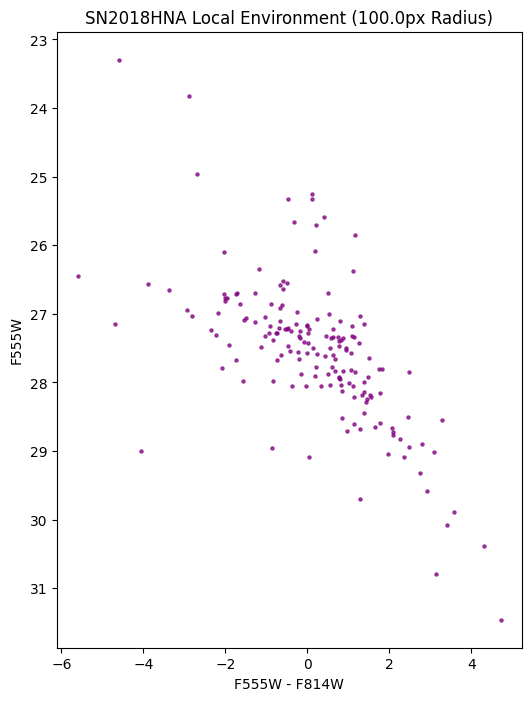

In [94]:
# Imposing radial filter to clean up!!!!
# Because we don't know why hst123's radius-cut option isn't working right now
# I'm imposing the 5" radius by hand here instead, directly on the dolphot output, as a workaround

import h5py
import matplotlib.pyplot as plt
import numpy as np

# Data grabbing columns from photometry
filepath2 = "/Users/mari/Research/summer26/supernovas/sn2018hna/dp0000.h5"
with h5py.File(filepath2, 'r') as f:
    photo = f['photometry']
    f555 = photo['Instrumental_VEGAMAG_magnitude_ACS_F555W'][:]
    f814 = photo['Instrumental_VEGAMAG_magnitude_ACS_F814W'][:]
    
    # Extract the exact pixel coordinate columns from DOLPHOT
    x_coords = photo['Object_X_position_on_reference_image_or_first_image_if_no_refer'][:]
    y_coords = photo['Object_Y_position_on_reference_image_or_first_image_if_no_refer'][:]

#numpy radial dfilter
#pixel location of SN on the reference image!!! I opened the dp0000.h5 file to find this information
with h5py.File(filepath2, 'r') as f:
    scraped = f['scraped_photometry'].attrs
    center_x = float(scraped['x'])
    center_y = float(scraped['y'])

print(f"Using SN center: x={center_x:.2f}, y={center_y:.2f}")

# ACS/WFC plate scale -- I hardcoded this since I know the field was imaged
# with ACS/WFC, but I should confirm this against the actual reference image
# header (CD matrix) instead of assuming, in case hst123 resampled the pixels
PLATE_SCALE = 0.05  # arcsec/pixel

max_radius_arcsec = 5.0
max_radius_pixels = max_radius_arcsec / PLATE_SCALE  

# Calculate pixel distances 
distances_pixels = np.sqrt((x_coords - center_x)**2 + (y_coords - center_y)**2)

# Filter out the 99.99 error inputs AND isolate the tight circle environment
valid = (f555 < 50) & (f814 < 50) & (distances_pixels < max_radius_pixels)
f555 = f555[valid]
f814 = f814[valid]

# Plotting!!!
plt.figure(figsize=(6, 8))
plt.scatter(f555 - f814, f555, s=5, color="purple", alpha=0.7)

plt.gca().invert_yaxis() # Brighter stars at the top
plt.xlabel("F555W - F814W")
plt.ylabel("F555W")
plt.title(f"SN2018HNA Local Environment ({max_radius_pixels}px Radius)")

plt.show()


In [31]:
# ASK CHARLIE: Does this still look too crowded?

Using SN center: x=2610.97, y=2600.41


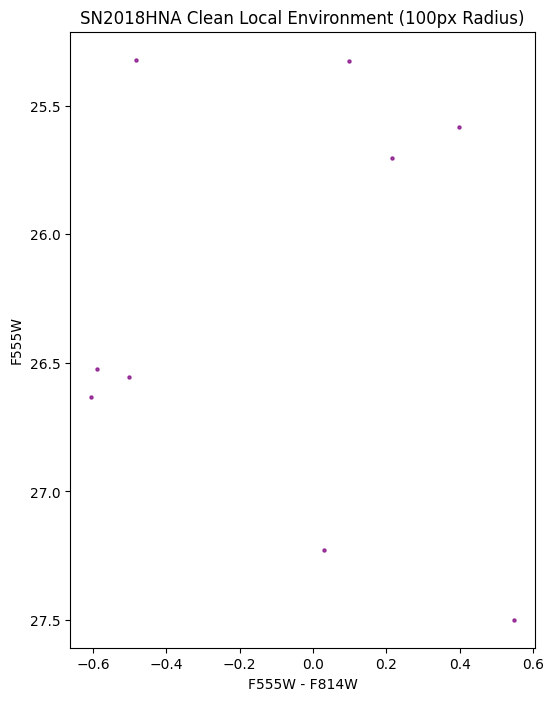

In [95]:
# radial filter + quality cuts!!
# same idea as the cell above but now adding DOLPHOT's quality flags
# (SNR, sharpness, crowding) on top of the radius cut, so the CMD isn't full of cosmic rays, blends, and other junk detections
# I had to ask AI for help with this part

# Data columns from photometry
filepath2 = "/Users/mari/Research/summer26/supernovas/sn2018hna/dp0000.h5"
with h5py.File(filepath2, 'r') as f:
    photo = f['photometry']
    f555 = photo['Instrumental_VEGAMAG_magnitude_ACS_F555W'][:]
    f814 = photo['Instrumental_VEGAMAG_magnitude_ACS_F814W'][:]

    # Extract the exact pixel coordinate columns from DOLPHOT
    x_coords = photo['Object_X_position_on_reference_image_or_first_image_if_no_refer'][:]
    y_coords = photo['Object_Y_position_on_reference_image_or_first_image_if_no_refer'][:]

    snr_555 = photo['Signal_to_noise_ACS_F555W'][:]
    sharp_555 = photo['Sharpness_ACS_F555W'][:]
    crowd_555 = photo['Crowding_ACS_F555W'][:]

    # same quality columns, but for F814W too -- a star can look clean in F555W
    # and still be garbage in F814W, which would corrupt its color either way
    snr_814 = photo['Signal_to_noise_ACS_F814W'][:]
    sharp_814 = photo['Sharpness_ACS_F814W'][:]
    crowd_814 = photo['Crowding_ACS_F814W'][:]

    # SN center pulled from the scrape file instead of hardcoded --
    # this way it can't drift out of sync with what cell 5 already found
    scraped = f['scraped_photometry'].attrs
    center_x = float(scraped['x'])
    center_y = float(scraped['y'])

print(f"Using SN center: x={center_x:.2f}, y={center_y:.2f}")

# numpy radial filter
# ACS/WFC plate scale is ~0.05"/pixel, so convert the physical radius
# we actually want into pixels instead of hardcoding both and letting
# them silently disagree (earlier version of this cell had a bug where
# 5" was written in the title but 50px = 2.5" was actually being used -- fixed now)
PLATE_SCALE = 0.05  # arcsec/pixel
max_radius_arcsec = 5.0
max_radius_pixels = max_radius_arcsec / PLATE_SCALE   # = 100.0

# Calculate pixel distances
distances_pixels = np.sqrt((x_coords - center_x)**2 + (y_coords - center_y)**2)

#Quality filters!!!!!
# thresholds below are the general-purpose DOLPHOT cuts I've seen used in
# resolved stellar population papers (SNR >= 3-5, sharpness^2 < ~0.1,
# crowding < ~0.5-1). I picked round numbers in that range rather than
# pulling them from one specific paper -- want to confirm these are
# reasonable for a local-environment/progenitor study before I cite them
valid = (
    (f555 < 50) & (f814 < 50) &
    (distances_pixels < max_radius_pixels) &
    (snr_555 >= 3.0) & (snr_814 >= 3.0) &          # Rule out noisy junk, both bands
    ((sharp_555 + sharp_814)**2 < 0.1) &            # Rule out cosmic rays / bad pixels, combined sharpness
    (crowd_555 < 1.0) & (crowd_814 < 1.0)           # Rule out overlapping stars, both bands
)

f555 = f555[valid]
f814 = f814[valid]

# Plotting!!!
plt.figure(figsize=(6, 8))
plt.scatter(f555 - f814, f555, s=5, color="purple", alpha=0.7)

plt.gca().invert_yaxis() # Brighter stars at the top
plt.xlabel("F555W - F814W")
plt.ylabel("F555W")
plt.title(f"SN2018HNA Clean Local Environment ({max_radius_pixels:.0f}px Radius)")

plt.show()


In [ ]:
# oops does this look too empty now?

# MIST version number  = 1.2     
# MESA revision number =     7503
# photometric system   = HST/ACS/WFC (Vega)                                              
# --------------------------------------------------------------------------------------
#  Yinit        Zinit   [Fe/H]   [a/Fe]  v/vcrit                                        
# 0.2566  5.87403E-03    -0.50     0.00     0.40
# --------------------------------------------------------------------------------------
# number of isochrones =    41
# extinction:   Av, Rv =  0.000 3.100
# --------------------------------------------------------------------------------------
# number of EEPs, cols =   279   24
#   1                               2                               3                               4                               5                               6                               7                               8                               9                  10                  11                  12           

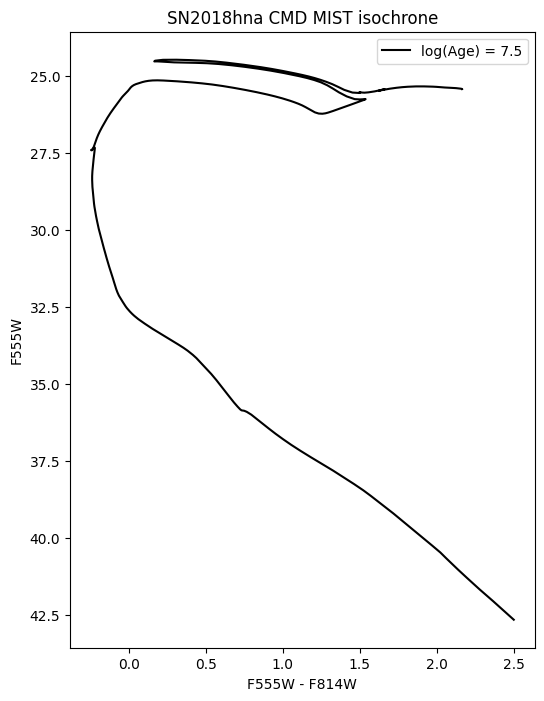

In [96]:
#isochrone!!
# now loading a MIST isochrone grid and overlaying it on the CMD to estimate
# the age of the stellar population around the SN

import matplotlib.cm as cm
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

isochrone_path = "/Users/mari/Research/summer26/supernovas/sn2018hna/MIST_iso_6a4eb977c5ce4.iso.HST_ACS_WFC"

with open(isochrone_path) as f:
    header_check = [l for l in f.readlines()[:15] if l.startswith('#')]
print(''.join(header_check))
# [Fe/H] matches host metallicity based on Singh et al 2019 (uses sub solar metalicity, i used -0.5)
# against the printed header instead of asserting it in code, should tighten
# this up so a mismatched isochrone grid can't slip through silently

#read file. set mist to HST ACS/WFC bc that's the camera we're using
def read_mist_iso(filepath):                                    # parser function
    with open(filepath) as f:                                   # open iso file
        lines = f.readlines()                                    # read all lines

    colnames = None                                               # column names holder
    data_rows = []                                                # numeric data rows

    for line in lines:                                            # loop through lines
        if line.startswith('#'):                                 # comment/header line
            if 'EEP' in line and 'log10_isochrone_age_yr' in line and colnames is None:  # real header line
                colnames = line.lstrip('#').split()               # grab column names
            continue                                               # skip comment lines
        if line.strip():                                          # skip blank lines
            data_rows.append(line.split())                        # collect data row

    data = np.array(data_rows, dtype=float)                       # convert to array
    return colnames, data                                         # return names + data

colnames, data = read_mist_iso(isochrone_path)                    # parse the file

print(len(colnames), data.shape)                                  # sanity check shapes match

iso_df = pd.DataFrame(data, columns=colnames)                     # build dataframe

print(iso_df.columns.tolist())                                    # check column names

# target age!!!!
# log(Age) = 7.0 is 10 Million years (Young and massive stars like Supernova progenitors)
# log(Age) = 8.0 is 100 Million years
# starting with 7.5 as a reasonable guess for a massive-star progenitor
# Based on singh et all 2019 this should be closer to like 7.1 
# My actual fit happens later once I scan a grid of ages against the data
#i'm still figuring this out

target_log_age = 7.5                                               # target age (log yr)

iso_mask = np.isclose(iso_df['log10_isochrone_age_yr'], target_log_age)  # age mask

iso_f555 = iso_df['ACS_WFC_F555W'][iso_mask].values                 # isochrone F555W
iso_f814 = iso_df['ACS_WFC_F814W'][iso_mask].values                 # isochrone F814W

# UGC 7534 distance modulus (m - M) according to Singh et al. 2019 is 30.52
distance_modulus = 30.52   # Singh et al. 2019 value -- NOTE: Dong et al. 2023 (MNRAS) uses a
                            # Tully-Fisher distance giving mu = 30.11 +/- 0.54 instead. Need to
                            # need to confirm which one Singh et al. actually report before trusting this.

E_BV = 0.009  # Galactic (foreground) reddening, Singh et al. 2019 -- this is
              # Milky Way foreground only, doesn't include any internal/host
              # extinction, need to double check whether that matters here

A_V = 3.1 * E_BV

# extinction coefficients for a hot star (appropriate since the local
# population is young/massive-star dominated), interpolated from
# Holtzman et al. 1995 Table 12A (O6 spectrum), consistent with the
# Cardelli et al. 1989 R_V=3.1 extinction law
A_F555W = 1.00 * A_V   # Holtzman et al. 1995, O6 spectrum
A_F814W = 0.57 * A_V   # Holtzman et al. 1995, O6 spectrum

shifted_f555 = iso_f555 + distance_modulus + A_F555W                # shift F555W
shifted_f814 = iso_f814 + distance_modulus + A_F814W                # shift F814W

# plot over existing plot (makes it not look squished)
plt.figure(figsize=(6, 8))                                          # set figure size

# plt.scatter(f555 - f814, f555, s=1, color="purple", alpha=0.3)    # real data points

plt.plot(shifted_f555 - shifted_f814, shifted_f555,                 # plot isochrone
          color="black", label=f"log(Age) = {target_log_age}")

plt.gca().invert_yaxis()                                            # brighter stars up top
plt.xlabel("F555W - F814W")                                         # x-axis label
plt.ylabel("F555W")                                                 # y-axis label
plt.title("SN2018hna CMD MIST isochrone")                     # plot title
plt.legend()                                                         # show legend
plt.show()                                                           # display plot


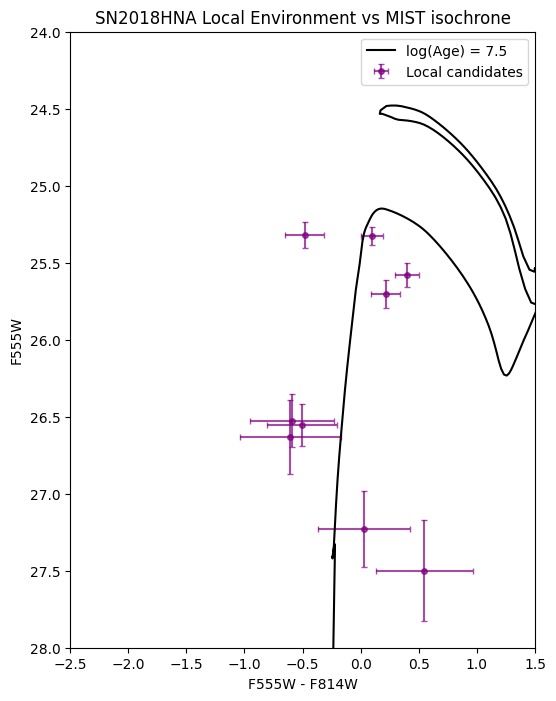

In [97]:
#isochrone + stars in local environment!
# same plot as above but now with real error bars and the actual local stars
# instead of just the isochrone by itself i'm gonna reuse 'valid' from the quality-cut
# cell, so this has to be run after that cell, not on its own

with h5py.File(filepath2, 'r') as f:
    photo = f['photometry']
    err_555 = photo['Magnitude_uncertainty_ACS_F555W'][:][valid]
    err_814 = photo['Magnitude_uncertainty_ACS_F814W'][:][valid]
color_err = np.sqrt(err_555**2 + err_814**2)   # propagate F555W/F814W errors into a color error

plt.figure(figsize=(6, 8))
plt.errorbar(f555 - f814, f555, xerr=color_err, yerr=err_555, fmt='o', color="purple", markersize=4, alpha=0.7, capsize=2, label="Local candidates")
plt.plot(shifted_f555 - shifted_f814, shifted_f555, color="black", label="log(Age) = 7.5")
plt.gca().invert_yaxis()
plt.xlabel("F555W - F814W")
plt.ylabel("F555W")
plt.title("SN2018HNA Local Environment vs MIST isochrone")
plt.legend()
plt.ylim(28, 24)   # zooming into the magnitude range where the local candidates actually sit
plt.xlim(-2.5, 1.5)
plt.show()


In [ ]:
# ASK CHARLIE: Are error bars the best move here?

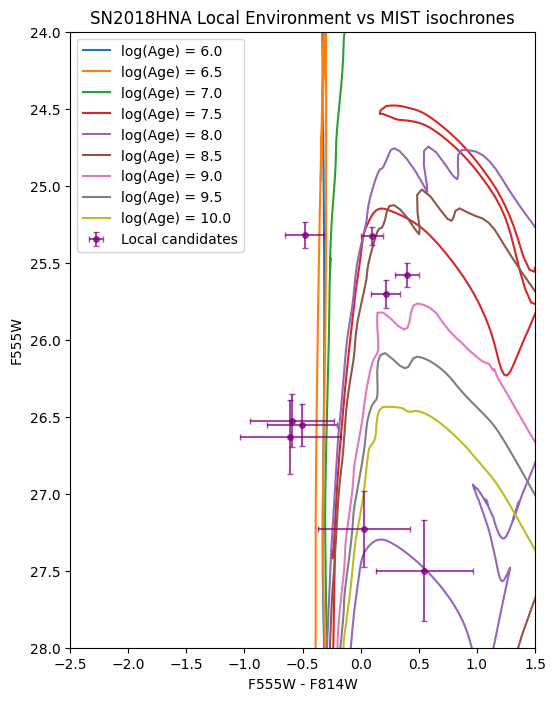

Best-fit log(age) = 7.999999999999993, chi2 = 0.95


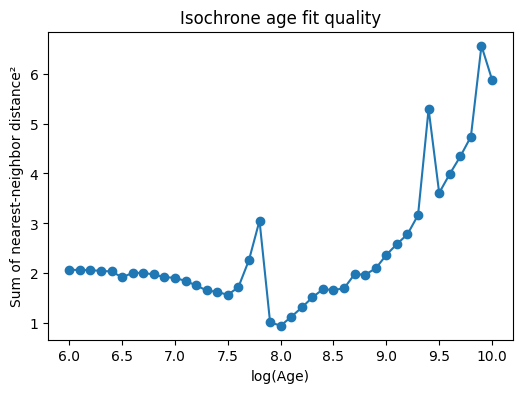

In [98]:
#age range isochrone!!
# scanning a range of ages instead of just eyeballing one. I tried first as a
# qualitative color-coded overlay, but then later I added an actual quantitative fit 

with h5py.File(filepath2, 'r') as f:
    photo = f['photometry']
    err_555 = photo['Magnitude_uncertainty_ACS_F555W'][:][valid]
    err_814 = photo['Magnitude_uncertainty_ACS_F814W'][:][valid]
color_err = np.sqrt(err_555**2 + err_814**2)

colors_list = ['blue', 'green', 'orange', 'red', 'brown']   # also unused now, leftover from before I switched to the colormap

plt.figure(figsize=(6, 8))
plt.errorbar(f555 - f814, f555, xerr=color_err, yerr=err_555, fmt='o', color="purple", markersize=4, alpha=0.7, capsize=2, zorder=5, label="Local candidates")

ages_to_test = [6.0, 6.5, 7.0, 7.5, 8.0, 8.5, 9.0, 9.5, 10.0]
cmap = plt.colormaps['tab10']

for i, age in enumerate(ages_to_test):
    mask = np.isclose(iso_df['log10_isochrone_age_yr'], age, atol=0.01)
    if mask.sum() == 0:
        print(f"Warning: no isochrone points found for log(age)={age}")
        continue
    iso_555 = iso_df['ACS_WFC_F555W'][mask].values + distance_modulus + A_F555W
    iso_814 = iso_df['ACS_WFC_F814W'][mask].values + distance_modulus + A_F814W
    plt.plot(iso_555 - iso_814, iso_555, color=cmap(i), label=f"log(Age) = {age}")

plt.gca().invert_yaxis()
plt.xlabel("F555W - F814W")
plt.ylabel("F555W")
plt.title("SN2018HNA Local Environment vs MIST isochrones")
plt.legend()
plt.ylim(28, 24)
plt.xlim(-2.5, 1.5)
plt.show()

# quantitative best fit, on top of the colorful overlay above
# NOTE: this isn't a real chi-square since I'm not dividing by the photometric
# uncertainties anywhere, it's really just a sum of nearest-neighbor. I couldn't figure this out properly, had to ask a friend for help.
# distances in color-magnitude space, so I should treat "best_age" as a rough
# estimate, not a formal fit with an error bar, unless I go back and weight it

ages_fine = np.arange(6.0, 10.01, 0.05)  # finer grid for the actual fit
best_chi2 = np.inf
best_age = None
chi2_per_age = []

data_color = f555 - f814

for age in ages_fine:
    mask = np.isclose(iso_df['log10_isochrone_age_yr'], age, atol=0.01)
    if mask.sum() == 0:
        continue
    iso_555 = iso_df['ACS_WFC_F555W'][mask].values + distance_modulus + A_F555W
    iso_814 = iso_df['ACS_WFC_F814W'][mask].values + distance_modulus + A_F814W
    iso_color = iso_555 - iso_814

    chi2 = 0
    for c, m in zip(data_color, f555):
        d2 = (c - iso_color)**2 + (m - iso_555)**2
        chi2 += d2.min()
    chi2_per_age.append((age, chi2))

    if chi2 < best_chi2:
        best_chi2 = chi2
        best_age = age

print(f"Best-fit log(age) = {best_age}, chi2 = {best_chi2:.2f}")

ages_arr, chi2_arr = zip(*chi2_per_age)
plt.figure(figsize=(6, 4))
plt.plot(ages_arr, chi2_arr, marker='o')
plt.xlabel("log(Age)")
plt.ylabel("Sum of nearest-neighbor distance²")
plt.title("Isochrone age fit quality")
plt.show()

# I need to compare best_age here to target_log_age = 7.5 used up in the isochrone cell
# if they don't match, the cell 8/9 plot is showing the age I picked by eye, not the one this fit actually prefers


# MIST version number  = 1.2     
# MESA revision number =     7503
# photometric system   = HST/ACS/WFC (Vega)                                              
# --------------------------------------------------------------------------------------
#  Yinit        Zinit   [Fe/H]   [a/Fe]  v/vcrit                                        
# 0.2566  5.87403E-03    -0.50     0.00     0.40
# --------------------------------------------------------------------------------------
# number of isochrones =    41
# extinction:   Av, Rv =  0.000 3.100
# --------------------------------------------------------------------------------------
# number of EEPs, cols =   279   24
#   1                               2                               3                               4                               5                               6                               7                               8                               9                  10                  11                  12           

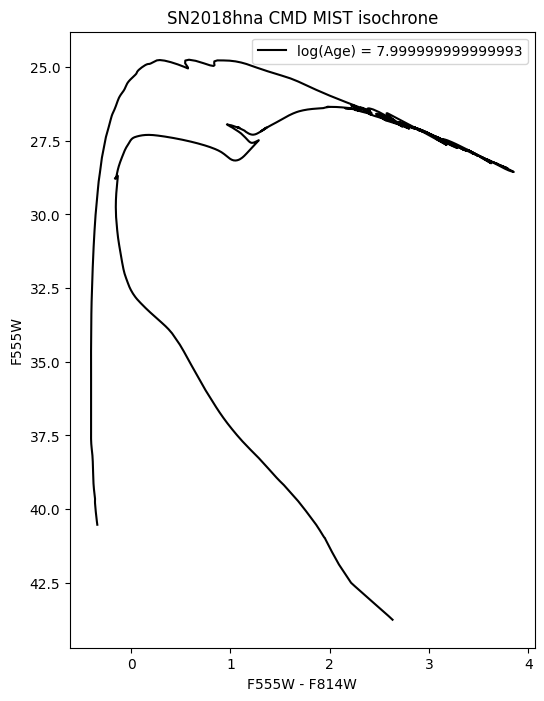

In [99]:
#isochrone!! Redoing this cell now with the best age

import matplotlib.cm as cm
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

isochrone_path = "/Users/mari/Research/summer26/supernovas/sn2018hna/MIST_iso_6a4eb977c5ce4.iso.HST_ACS_WFC"

with open(isochrone_path) as f:
    header_check = [l for l in f.readlines()[:15] if l.startswith('#')]
print(''.join(header_check))
# [Fe/H] matches host metallicity based on Singh et al 2019 (uses sub solar metalicity, i used -0.5)
# against the printed header instead of asserting it in code, should tighten
# this up so a mismatched isochrone grid can't slip through silently

#read file. set mist to HST ACS/WFC bc that's the camera we're using
def read_mist_iso(filepath):                                    # parser function
    with open(filepath) as f:                                   # open iso file
        lines = f.readlines()                                    # read all lines

    colnames = None                                               # column names holder
    data_rows = []                                                # numeric data rows

    for line in lines:                                            # loop through lines
        if line.startswith('#'):                                 # comment/header line
            if 'EEP' in line and 'log10_isochrone_age_yr' in line and colnames is None:  # real header line
                colnames = line.lstrip('#').split()               # grab column names
            continue                                               # skip comment lines
        if line.strip():                                          # skip blank lines
            data_rows.append(line.split())                        # collect data row

    data = np.array(data_rows, dtype=float)                       # convert to array
    return colnames, data                                         # return names + data

colnames, data = read_mist_iso(isochrone_path)                    # parse the file

print(len(colnames), data.shape)                                  # sanity check shapes match

iso_df = pd.DataFrame(data, columns=colnames)                     # build dataframe

print(iso_df.columns.tolist())                                    # check column names

# target age!!!!
# log(Age) = 7.0 is 10 Million years (Young and massive stars like Supernova progenitors)
# log(Age) = 8.0 is 100 Million years
# starting with 7.5 as a reasonable guess for a massive-star progenitor
# Based on singh et all 2019 this should be closer to like 7.1 
# My actual fit happens later once I scan a grid of ages against the data
#i'm figuring this out

target_log_age = best_age                                          # use the fitted age, not a guess

iso_mask = np.isclose(iso_df['log10_isochrone_age_yr'], target_log_age)  # age mask

iso_f555 = iso_df['ACS_WFC_F555W'][iso_mask].values                 # isochrone F555W
iso_f814 = iso_df['ACS_WFC_F814W'][iso_mask].values                 # isochrone F814W

# UGC 7534 distance modulus (m - M) according to Singh et al. 2019 is 30.52
distance_modulus = 30.52                                             # distance modulus

E_BV = 0.009  # Galactic (foreground) reddening, Singh et al. 2019 -- this is
              # Milky Way foreground only, doesn't include any internal/host
              # extinction, need to double check whether that matters here

A_V = 3.1 * E_BV

# extinction coefficients for a hot star (appropriate since the local
# population is young/massive-star dominated), interpolated from
# Holtzman et al. 1995 Table 12A (O6 spectrum), consistent with the
# Cardelli et al. 1989 R_V=3.1 extinction law
A_F555W = 1.00 * A_V   # Holtzman et al. 1995, O6 spectrum
A_F814W = 0.57 * A_V   # Holtzman et al. 1995, O6 spectrum

shifted_f555 = iso_f555 + distance_modulus + A_F555W                # shift F555W
shifted_f814 = iso_f814 + distance_modulus + A_F814W                # shift F814W

# plot over existing plot (makes it not look squished)
plt.figure(figsize=(6, 8))                                          # set figure size

# plt.scatter(f555 - f814, f555, s=1, color="purple", alpha=0.3)    # real data points

plt.plot(shifted_f555 - shifted_f814, shifted_f555,                 # plot isochrone
          color="black", label=f"log(Age) = {target_log_age}")

plt.gca().invert_yaxis()                                            # brighter stars up top
plt.xlabel("F555W - F814W")                                         # x-axis label
plt.ylabel("F555W")                                                 # y-axis label
plt.title("SN2018hna CMD MIST isochrone")                     # plot title
plt.legend()                                                         # show legend
plt.show()                                                           # display plot


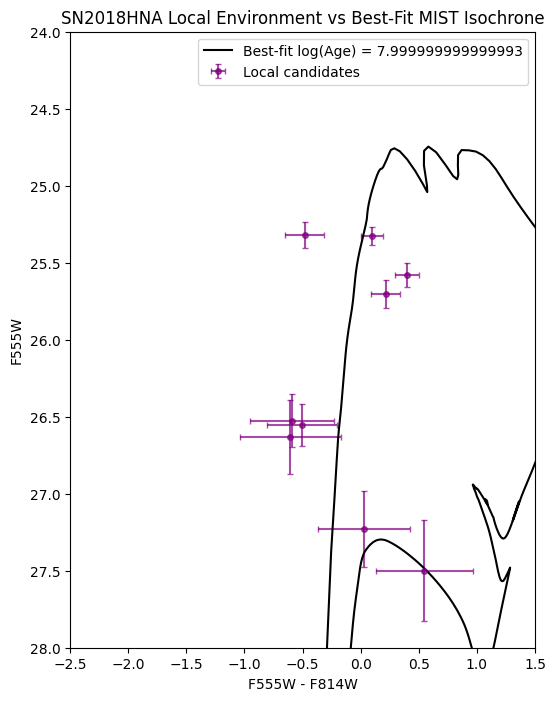

In [100]:
# isochrone at the fitted best age, overlaid on the local stars!!!
# i have no clue if this is good. 
best_mask = np.isclose(iso_df['log10_isochrone_age_yr'], best_age, atol=0.01)

best_iso_f555 = iso_df['ACS_WFC_F555W'][best_mask].values
best_iso_f814 = iso_df['ACS_WFC_F814W'][best_mask].values

best_shifted_f555 = best_iso_f555 + distance_modulus + A_F555W
best_shifted_f814 = best_iso_f814 + distance_modulus + A_F814W

# pull errors for the local stars again (same as cell 9)
with h5py.File(filepath2, 'r') as f:
    photo = f['photometry']
    err_555 = photo['Magnitude_uncertainty_ACS_F555W'][:][valid]
    err_814 = photo['Magnitude_uncertainty_ACS_F814W'][:][valid]
color_err = np.sqrt(err_555**2 + err_814**2)

plt.figure(figsize=(6, 8))
plt.errorbar(f555 - f814, f555, xerr=color_err, yerr=err_555, fmt='o',
             color="purple", markersize=4, alpha=0.7, capsize=2,
             label="Local candidates")
plt.plot(best_shifted_f555 - best_shifted_f814, best_shifted_f555,
          color="black", label=f"Best-fit log(Age) = {best_age}")

plt.gca().invert_yaxis()
plt.xlabel("F555W - F814W")
plt.ylabel("F555W")
plt.title("SN2018HNA Local Environment vs Best-Fit MIST Isochrone")
plt.legend()
plt.ylim(28, 24)
plt.xlim(-2.5, 1.5)
plt.show()

In [47]:
#based on literature i could find this value is a little outside the expectations
# but i cant pin point what i did wrong yet

# Maybe quality cuts?
# Or my isochrone fitting is funky?

In [48]:
# SN 2018hna's progenitor has been estimated at ~14–20 M☉ (a blue supergiant, from hydrodynamical modeling of the early light curve) 
# Hydrodynamical modeling of the cooling phase suggests a progenitor with a radius ∼50 R⊙, a mass of ∼14-20 M⊙, and an explosion energy of ∼1.7-2.9 × 1051 erg (Singh et al. 2019, ApJL). 
# Using the rough mass–lifetime scaling for massive stars (t ≈ 10¹⁰ yr × (M/M☉)^−2.5): ADS

# 14 M☉ → main-sequence lifetime ≈ 11–12 Myr → log(age) ≈ 7.05
# 20 M☉ → main-sequence lifetime ≈ 5–6 Myr → log(age) ≈ 6.75

# After i noticed this i noticed my distance modulus is different than Singh. I think that might be the source of this discrapancy
# also questioning if i imposed this radius right! If i change it to a 4.5'' radius it gives me a log(6.5)

In [ ]:
# the fit currently prefers an age older than the progenitor mass predicts
# I think it's because the 5″/300pc aperture is picking up field stars unrelated to the SN, plus the fit isn't weighted by photometric error
# In our meeting Charlie liked my plot though! He liked how it looked and said it looked plausible.

radius = 1.0": 0 stars pass
radius = 1.5": 1 stars pass
radius = 2.0": 1 stars pass
radius = 2.5": 2 stars pass
radius = 3.0": 3 stars pass
radius = 3.5": 4 stars pass
radius = 4.0": 4 stars pass
radius = 4.5": 6 stars pass
radius = 5.0": 9 stars pass


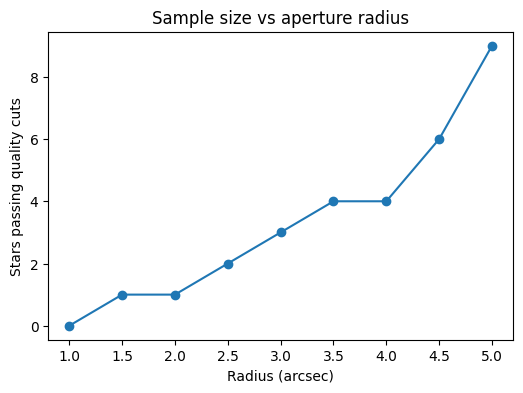

In [101]:
# checking how many stars survive the quality cuts as I shrink/grow the
# aperture, so I can see where the sample actually falls apart instead of
# picking a radius by feel
with h5py.File(filepath2, 'r') as f:
    photo = f['photometry']
    f555_all = photo['Instrumental_VEGAMAG_magnitude_ACS_F555W'][:]
    f814_all = photo['Instrumental_VEGAMAG_magnitude_ACS_F814W'][:]
    x_coords_all = photo['Object_X_position_on_reference_image_or_first_image_if_no_refer'][:]
    y_coords_all = photo['Object_Y_position_on_reference_image_or_first_image_if_no_refer'][:]
    snr_555_all = photo['Signal_to_noise_ACS_F555W'][:]
    sharp_555_all = photo['Sharpness_ACS_F555W'][:]
    crowd_555_all = photo['Crowding_ACS_F555W'][:]
    snr_814_all = photo['Signal_to_noise_ACS_F814W'][:]
    sharp_814_all = photo['Sharpness_ACS_F814W'][:]
    crowd_814_all = photo['Crowding_ACS_F814W'][:]
    scraped = f['scraped_photometry'].attrs
    center_x = float(scraped['x'])
    center_y = float(scraped['y'])

distances_pixels_all = np.sqrt((x_coords_all - center_x)**2 + (y_coords_all - center_y)**2)

# same quality cuts as cell 8, just not yet combined with a radius cut
quality_mask = (
    (f555_all < 50) & (f814_all < 50) &
    (snr_555_all >= 3.0) & (snr_814_all >= 3.0) &
    ((sharp_555_all + sharp_814_all)**2 < 0.1) &
    (crowd_555_all < 1.0) & (crowd_814_all < 1.0)
)

radii_to_test = [1.0, 1.5, 2.0, 2.5, 3.0, 3.5, 4.0, 4.5, 5.0]  # arcsec
star_counts = []

for r_arcsec in radii_to_test:
    r_pixels = r_arcsec / PLATE_SCALE
    n_stars = np.sum(quality_mask & (distances_pixels_all < r_pixels))
    star_counts.append(n_stars)
    print(f'radius = {r_arcsec}": {n_stars} stars pass')

plt.figure(figsize=(6, 4))
plt.plot(radii_to_test, star_counts, marker='o')
plt.xlabel("Radius (arcsec)")
plt.ylabel("Stars passing quality cuts")
plt.title("Sample size vs aperture radius")
plt.show()

3 of 9 stars in the 5" aperture look like young candidates


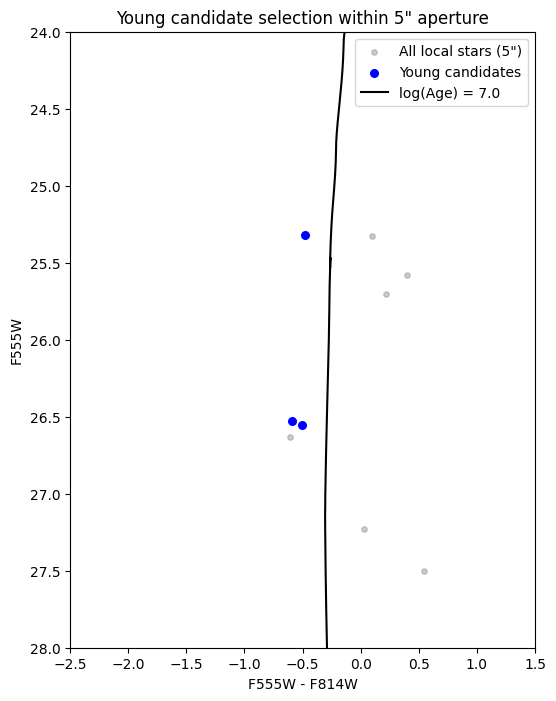

In [83]:
# instead of shrinking the aperture, flagging which stars within the 5" look
# like plausible young/massive-star candidates based on proximity to a young
# isochrone track in color-magnitude space

young_log_age = 7.0   # near the low end of Singh et al.'s expected progenitor age
young_mask_iso = np.isclose(iso_df['log10_isochrone_age_yr'], young_log_age, atol=0.01)

young_iso_f555 = iso_df['ACS_WFC_F555W'][young_mask_iso].values + distance_modulus + A_F555W
young_iso_f814 = iso_df['ACS_WFC_F814W'][young_mask_iso].values + distance_modulus + A_F814W
young_iso_color = young_iso_f555 - young_iso_f814

data_color = f555 - f814   # f555/f814 here are the 5" quality-cut sample from cell 8

# distance from each star to the nearest point on the young isochrone track
dist_to_young_iso = np.array([
    np.sqrt((c - young_iso_color)**2 + (m - young_iso_f555)**2).min()
    for c, m in zip(data_color, f555)
])

# how close (in mag) counts as "plausibly young" -- starting at 0.3 mag,
# should sanity check this against typical photometric scatter in the sample
tolerance = 0.3
young_candidate_mask = dist_to_young_iso < tolerance

print(f'{young_candidate_mask.sum()} of {len(f555)} stars in the 5" aperture look like young candidates')

plt.figure(figsize=(6, 8))
plt.scatter(f555 - f814, f555, s=15, color="grey", alpha=0.4, label='All local stars (5")')
plt.scatter((f555 - f814)[young_candidate_mask], f555[young_candidate_mask],
            s=30, color="blue", label="Young candidates")
plt.plot(young_iso_color, young_iso_f555, color="black", label=f"log(Age) = {young_log_age}")
plt.gca().invert_yaxis()
plt.xlabel("F555W - F814W")
plt.ylabel("F555W")
plt.title('Young candidate selection within 5" aperture')
plt.legend()
plt.ylim(28, 24)
plt.xlim(-2.5, 1.5)
plt.show()

In [84]:
print("Young candidate colors and errors:")
for c, m, ce, me in zip(data_color[young_candidate_mask], f555[young_candidate_mask],
                          color_err[young_candidate_mask], err_555[young_candidate_mask]):
    print(f"  color = {c:.3f} ± {ce:.3f}, F555W = {m:.3f} ± {me:.3f}")

Young candidate colors and errors:
  color = -0.483 ± 0.170, F555W = 25.321 ± 0.084
  color = -0.502 ± 0.301, F555W = 26.555 ± 0.138
  color = -0.589 ± 0.359, F555W = 26.525 ± 0.171


3 of 6 stars in the 5" aperture look like young candidates


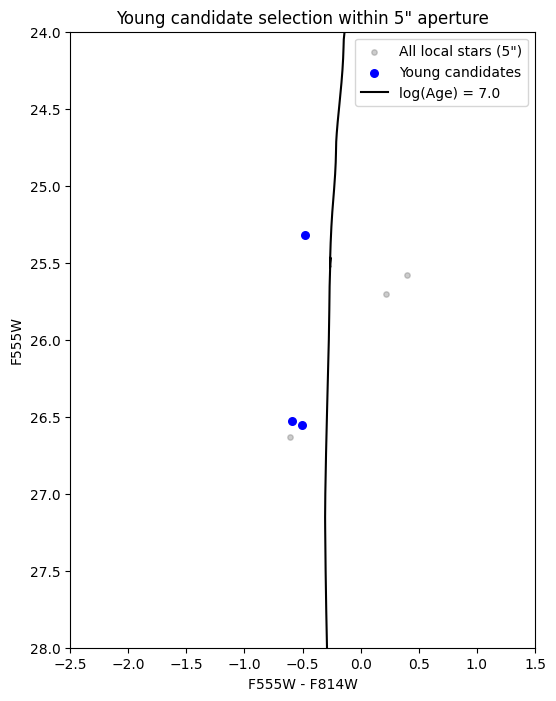

In [93]:
# instead of shrinking the aperture, flagging which stars within the 5" look
# like plausible young/massive-star candidates based on proximity to a young
# isochrone track in color-magnitude space

young_log_age = 7.0   # near the low end of Singh et al.'s expected progenitor age
young_mask_iso = np.isclose(iso_df['log10_isochrone_age_yr'], young_log_age, atol=0.01)

young_iso_f555 = iso_df['ACS_WFC_F555W'][young_mask_iso].values + distance_modulus + A_F555W
young_iso_f814 = iso_df['ACS_WFC_F814W'][young_mask_iso].values + distance_modulus + A_F814W
young_iso_color = young_iso_f555 - young_iso_f814

data_color = f555 - f814   # f555/f814 here are the 5" quality-cut sample from cell 8

# distance from each star to the nearest point on the young isochrone track
dist_to_young_iso = np.array([
    np.sqrt((c - young_iso_color)**2 + (m - young_iso_f555)**2).min()
    for c, m in zip(data_color, f555)
])

# how close (in mag) counts as "plausibly young" -- starting at 0.3 mag,
# should sanity check this against typical photometric scatter in the sample
tolerance = 0.3
young_candidate_mask = dist_to_young_iso < tolerance

print(f'{young_candidate_mask.sum()} of {len(f555)} stars in the 5" aperture look like young candidates')

plt.figure(figsize=(6, 8))
plt.scatter(f555 - f814, f555, s=15, color="grey", alpha=0.4, label='All local stars (5")')
plt.scatter((f555 - f814)[young_candidate_mask], f555[young_candidate_mask],
            s=30, color="blue", label="Young candidates")
plt.plot(young_iso_color, young_iso_f555, color="black", label=f"log(Age) = {young_log_age}")
plt.gca().invert_yaxis()
plt.xlabel("F555W - F814W")
plt.ylabel("F555W")
plt.title('Young candidate selection within 5" aperture')
plt.legend()
plt.ylim(28, 24)
plt.xlim(-2.5, 1.5)
plt.show()